# [LAB-07] 8-1. 이원분산분석

## #01. 준비작업

### 1. 라이브러리 참조

In [1]:
from jussam import load_data
from helpers import *
import numpy as np
from pandas import DataFrame

# 시각화 라이브러리
import seaborn as sb

# 분산분석을 위한 라이브러리
from pingouin import anova
from statsmodels.formula.api import ols

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/


### 2. 데이터 가져오기

- 식물의 성장이 햇빛 노출과 관수 빈도에 의해 영향을 받는지 여부를 알기 위해     
  씨앗을 심고 햇빛 노출과 물 주기를 다른 조건으로 하여 두 달 동안 자라게 한 후     
  각 식물의 높이를 인치 단위로 기록한 데이터

In [2]:
origin = load_data('sunlight_watering_growth')
origin.head()

📚 식물의 씨앗을 심고 햇빛 노출과 물 주기를 다른 조건으로 하여 두 달 동안 자라게 한 후 각 식물의 높이를 인치 단위로 기록한 데이터 (출처: 방송통신대학교 통계학개론)


,water,sun,height
0,daily,low,4.900
1,daily,low,7.900
2,daily,low,3.900
3,daily,low,5.100
4,daily,low,5.200


## #02. 데이터 분포 시각화

### 1. 관수빈도에 따른 햇빛 노출량별 따른 식물 높이 비교 (1/2) 

- 필요한 변수를 정의하고 데이터를 필터링한다.

In [3]:
# 필요한 변수 정의
field = 'height'        # 연속형 컬럼명
group_field = 'water'   # 명목형 컬럼명 1 (~~에 따른)
hue_field = 'sun'       # 명목형 컬럼명 2 (~~별)

# 그룹별 값의 종류 확인
group_values = origin[group_field].unique()
print(f'그룹별 값의 종류: {group_values}')

# 시각화 할 필드만 원본 데이터에서 추출
data = origin[[field, group_field, hue_field]]
data.head()

그룹별 값의 종류: ['daily' 'weekly']


,height,water,sun
0,4.900,daily,low
1,7.900,daily,low
2,3.900,daily,low
3,5.100,daily,low
4,5.200,daily,low


### 2. 관수빈도에 따른 햇빛 노출량별 따른 식물 높이 비교 (2/2) 

- 반복문을 수행하면서 데이터를 서브플롯으로 시각화 한다.

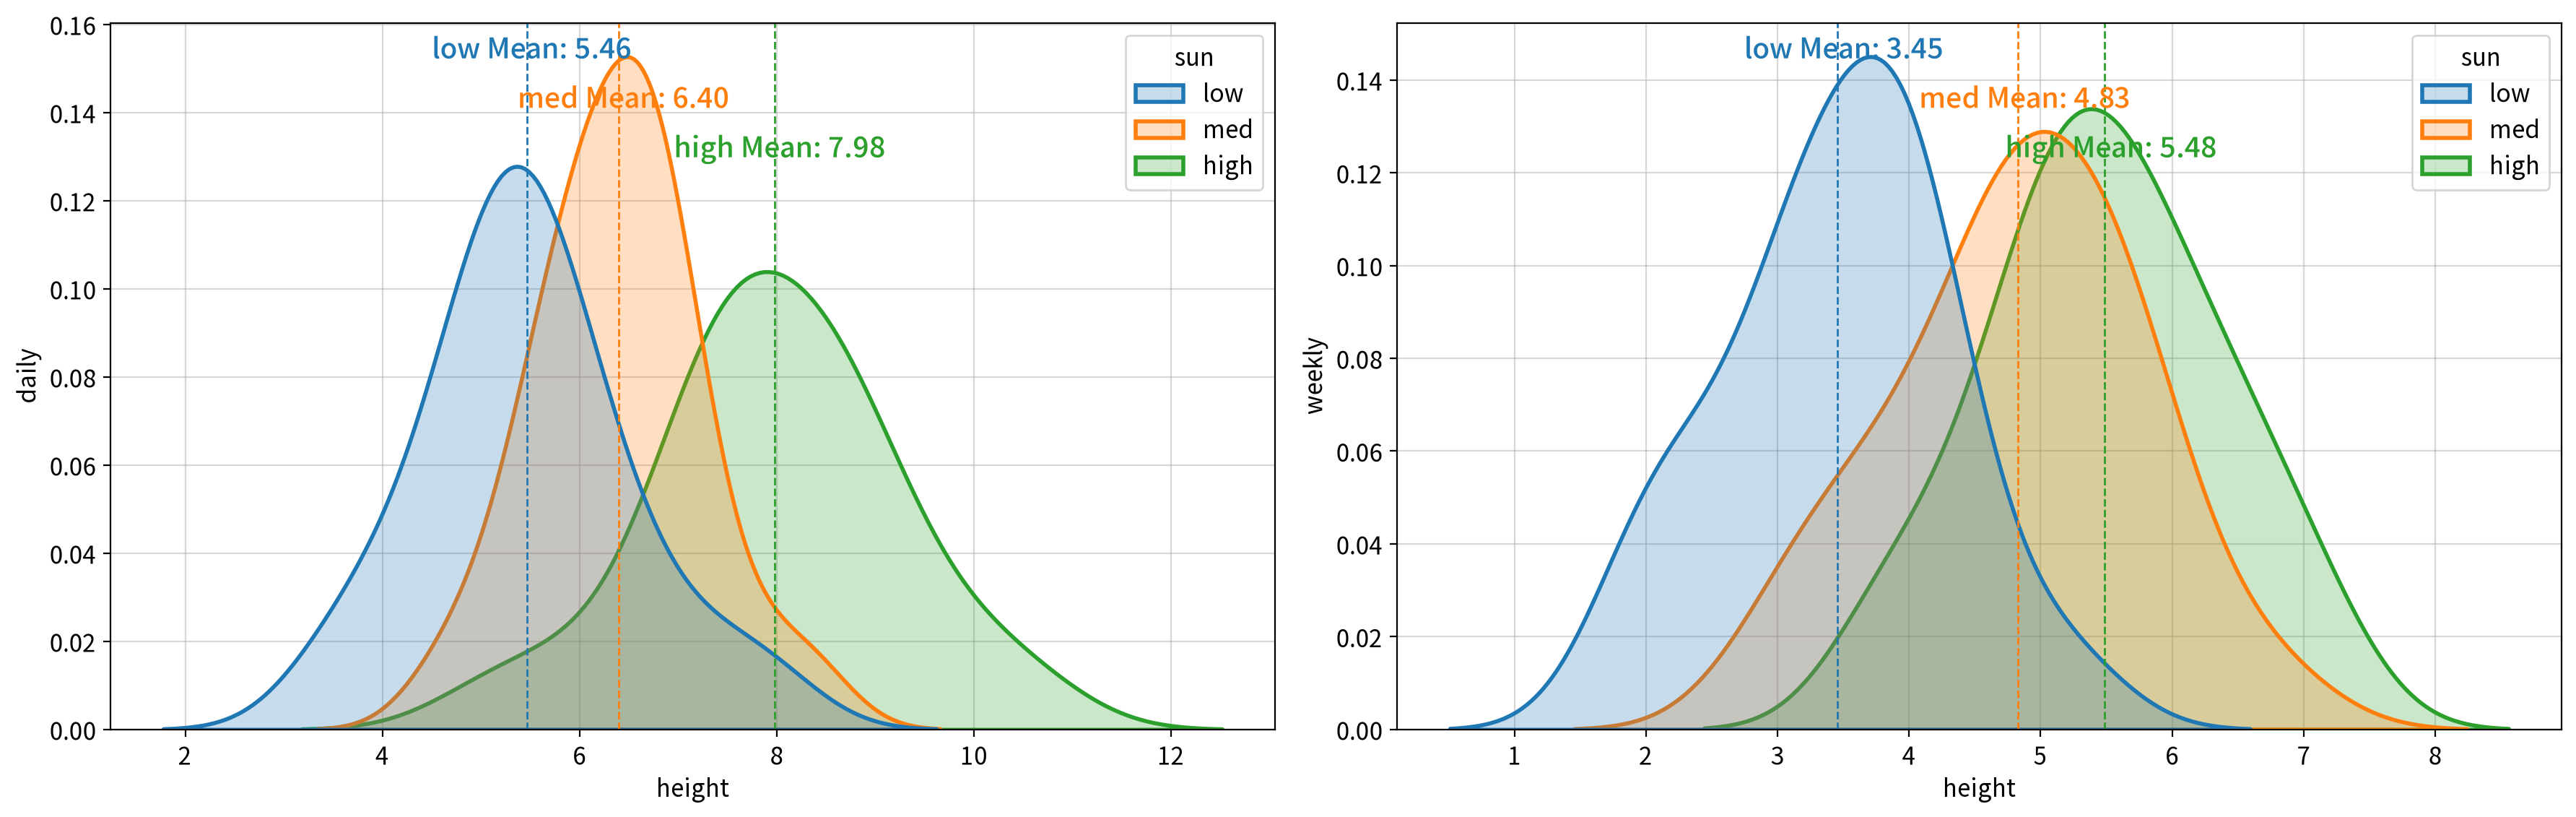

In [4]:
fig, ax = my_plot.init(cols=len(group_values), width=900, height=600)

for i, v in enumerate(group_values):
    temp = data[data[group_field] == v]
    
    my_plot.kdeplot(data=temp, x=field, hue=hue_field, fill=True, meanline=True, ax=ax[i])
    ax[i].set_ylabel(v)

my_plot.show()

### 3. 햇빛 노출량에 따른 관수빈도별 식물 높이 비교 (1/2)

In [5]:
# 필요한 변수 정의
field = 'height'        # 연속형 컬럼명
group_field = 'sun'     # 명목형 컬럼명 1 (~~에 따른)
hue_field = 'water'     # 명목형 컬럼명 2 (~~별)

# 그룹별 값의 종류 확인
group_values = origin[group_field].unique()
print(f'그룹별 값의 종류: {group_values}')

# 시각화 할 필드만 원본 데이터에서 추출
data = origin[[field, group_field, hue_field]]
data.head()

그룹별 값의 종류: ['low' 'med' 'high']


,height,sun,water
0,4.900,low,daily
1,7.900,low,daily
2,3.900,low,daily
3,5.100,low,daily
4,5.200,low,daily


### 4. 햇빛 노출량에 따른 관수빈도별 식물 높이 비교 (2/2)

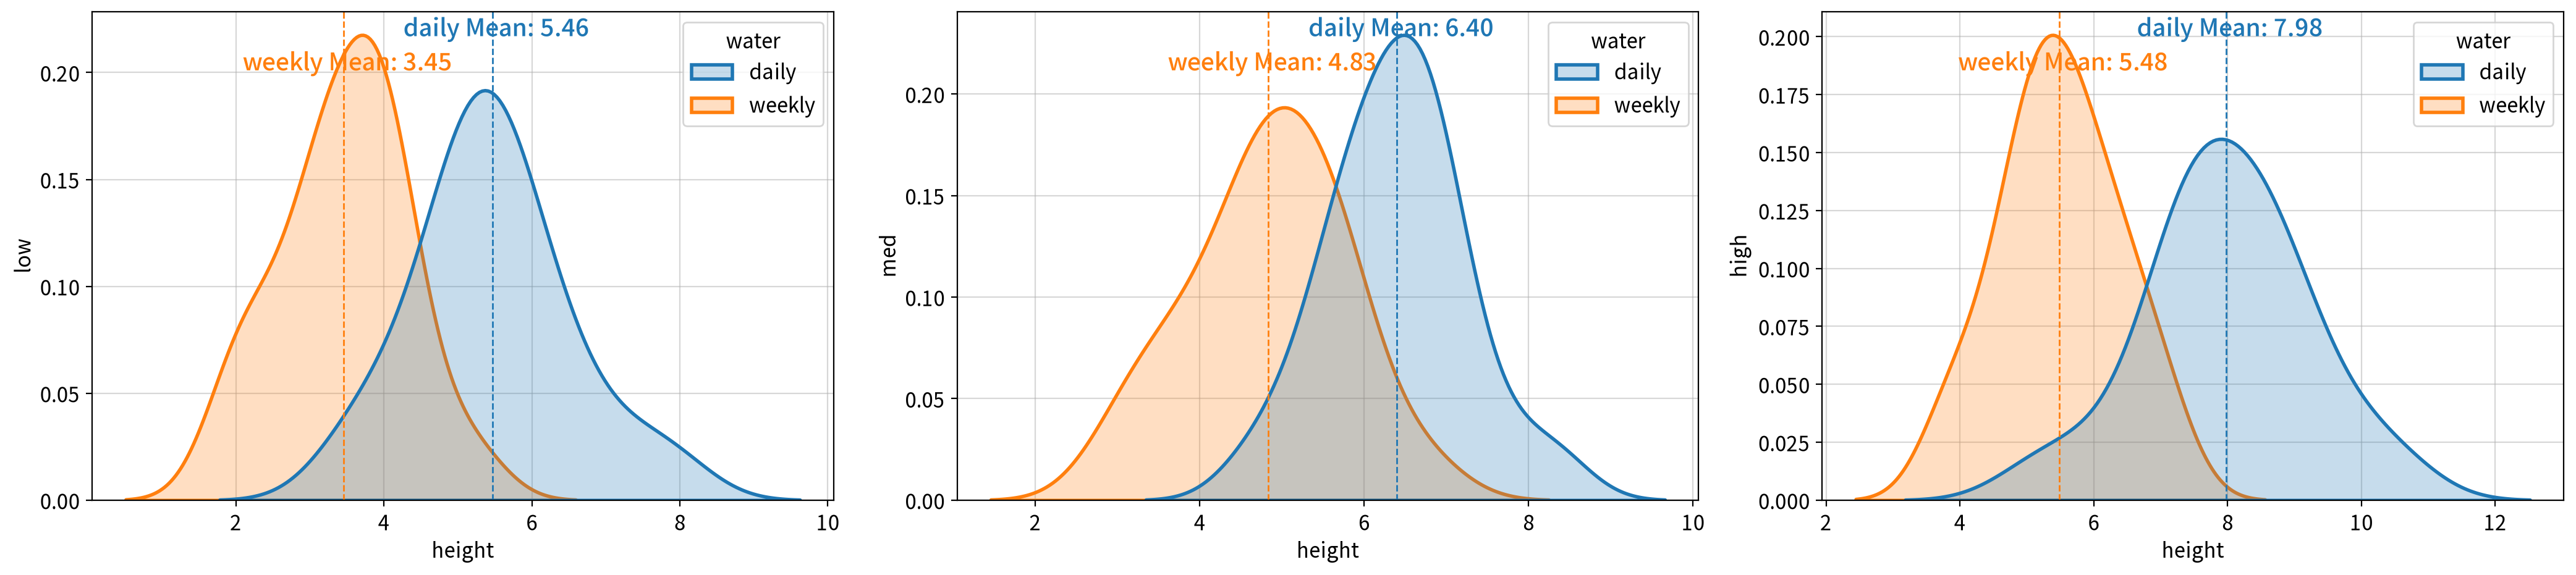

In [6]:
fig, ax = my_plot.init(cols=len(group_values), width=700, height=500)

for i, v in enumerate(group_values):
    temp = data[data[group_field] == v]
    
    my_plot.kdeplot(data=temp, x=field, hue=hue_field, fill=True, meanline=True, ax=ax[i])
    ax[i].set_ylabel(v)

my_plot.show()

## #03. 분산분석의 가정 확인

### 1. 모든 명목형의 조합에 따른 종속변수 재배치

In [7]:
data = origin.copy()
xname = ['water', 'sun']    # 명목형 변수의 이름
yname = 'height'            # 연속형 변수의 이름

# 두 명목형 변수의 모든 조합별로 연속형 변수 값을 별도의 컬럼으로 분리한다.
groups = {}
for i in data[xname[0]].unique():
    for j in data[xname[1]].unique():
        # 명목형 변수의 조합 조건에 맞는 데이터를 추출한다.
        filtered_data = data[(data[xname[0]] == i) & (data[xname[1]] == j)][yname]
        groups["{0}, {1}".format(i, j)] = filtered_data.reset_index(drop=True)

# 조합별 표본 크기가 다를 수 있으므로 DataFrame으로 결합하면 짧은 쪽은 NaN으로 채워진다.
# test_assumptions는 내부적으로 결측치를 제거한 뒤 검정하므로 문제되지 않는다.
group_df = DataFrame(groups)
group_df.head()

,"daily, low","daily, med","daily, high","weekly, low","weekly, med","weekly, high"
0,4.900,5.600,8.600,3.900,4.800,5.200
1,7.900,6.500,8.800,3.300,3.600,4.700
2,3.900,6.500,9.200,4.300,5.700,6.900
3,5.100,6.000,7.100,3.300,4.100,5.100
4,5.200,7.100,8.600,4.500,4.600,7.100


### 2. 정규성에 따른 등분산성 검정

In [8]:
# 정규성(normaltest)과 등분산성(Bartlett/Levene) 가정을 일괄 검정한다.
rdf = my_stats.test_assumptions(group_df)
display(rdf)

# 등분산성 충족 여부 (이후 사후검정 방법 선택에 사용)
equal_var = bool(rdf.loc[rdf['test'] == 'equal_var', 'result'].iloc[0])
equal_var

,test,statistic,p-value,result
field,,,,
"daily, low",normaltest,1.462,0.482,True
"daily, med",normaltest,0.867,0.648,True
"daily, high",normaltest,0.802,0.670,True
"weekly, low",normaltest,0.074,0.964,True
"weekly, med",normaltest,0.161,0.923,True
"weekly, high",normaltest,0.053,0.974,True
Bartlett,equal_var,4.488,0.481,True


True

## #03. 이원분산분석 수행

### 1. 가정 충족 여부에 따른 분기

- **등분산성 충족 시**: 일반적인 이원분산분석(`pingouin.anova`)을 수행한다.
- **등분산성 미충족 시**: 이원분산분석에는 Welch 같은 적절한 대안이 없으므로, 등분산을 가정하지 않는 **선형모형(`statsmodels` OLS + HC3 강건표준오차)** 기반의 Type-II ANOVA로 전환한다.

In [9]:
# 분석 변수 정의
data = origin.copy()
xname = ['water', 'sun']   # 명목형(독립) 변수
yname = 'height'           # 연속형(종속) 변수

# 등분산성 가정(equal_var) 충족 여부에 따라 분석 방법 분기
if equal_var:
    # [등분산 충족] 일반 이원분산분석
    aov = anova(data=data, dv=yname, between=xname).round(4)
    aov.insert(0, 'test', 'two-way ANOVA')
    # 유의성 판정 컬럼 추가 (p < 0.05 이면 효과 존재)
    aov['significant'] = aov['p_unc'] < 0.05

    # 효과크기(np2, partial eta-squared) 해석 (≥0.14 큼 / ≥0.06 중간 / ≥0.01 작음)
    conditions = [aov['np2'] >= 0.14, 
                  aov['np2'] >= 0.06, 
                  aov['np2'] >= 0.01]
    aov['effect_size'] = np.select(conditions, ['Large', 'Medium', 'Small'], 
                                   default='Negligible')
else:
    # [등분산 미충족] 등분산을 가정하지 않는 선형모형(HC3) 기반 Type-II ANOVA
    model = ols(f'{yname} ~ C({xname[0]}) * C({xname[1]})', data=data)
    fit = model.fit(cov_type='HC3')
    aov = sm.stats.anova_lm(fit, typ=2, robust='hc3').round(4)
    aov.insert(0, 'test', 'OLS (HC3) Type-II ANOVA')
    # 유의성 판정 컬럼 추가 (p < 0.05 이면 효과 존재)
    # -> p-value 컬럼명이 'PR(>F)'로 되어있으므로 해당 컬럼명을 사용
    aov['significant'] = aov['PR(>F)'] < 0.05


aov

,test,Source,SS,DF,MS,F,p_unc,np2,significant,effect_size
0,two-way ANOVA,water,122.816,1,122.816,130.529,0.000,0.534,True,Large
1,two-way ANOVA,sun,103.292,2,51.646,54.889,0.000,0.491,True,Large
2,two-way ANOVA,water * sun,4.327,2,2.164,2.300,0.105,0.039,False,Small
3,two-way ANOVA,Residual,107.264,114,0.941,NaN,NaN,NaN,False,Negligible


### 💡 인사이트

- **관수 빈도(water) 주효과는 유의**하다 (p < 0.001). 효과크기(np2=0.534)가 매우 커서, 매일 물을 준 식물(daily)이 주 1회 물을 준 식물(weekly)보다 분명하게 더 크게 자랐다.
- **햇빛 노출(sun) 주효과도 유의**하다 (p < 0.001, np2=0.491). 햇빛 노출량이 많을수록(high > med > low) 식물이 더 크게 자랐다.
- **상호작용효과(water × sun)는 유의하지 않다** (p = 0.105 > 0.05). 효과크기 라벨은 Small(np2=0.039)이지만 통계적으로 유의하지 않으므로, 관수 빈도가 미치는 효과의 크기가 햇빛 노출 수준에 따라 크게 달라지지 않는다고 본다. 즉 두 요인은 서로 **독립적·가산적(additive)** 으로 식물 성장에 기여한다고 해석할 수 있다.
- **결론**: 식물 성장(height)은 관수 빈도와 햇빛 노출 각각에 의해 강하게 영향을 받으며, 두 요인의 결합 방식에 따른 시너지/상쇄(상호작용)는 통계적으로 확인되지 않았다.

## #04. 이원분산분석 시각화

### 1. 햇빛 노출량에 따른 관수 빈도별 평균 식물 높이

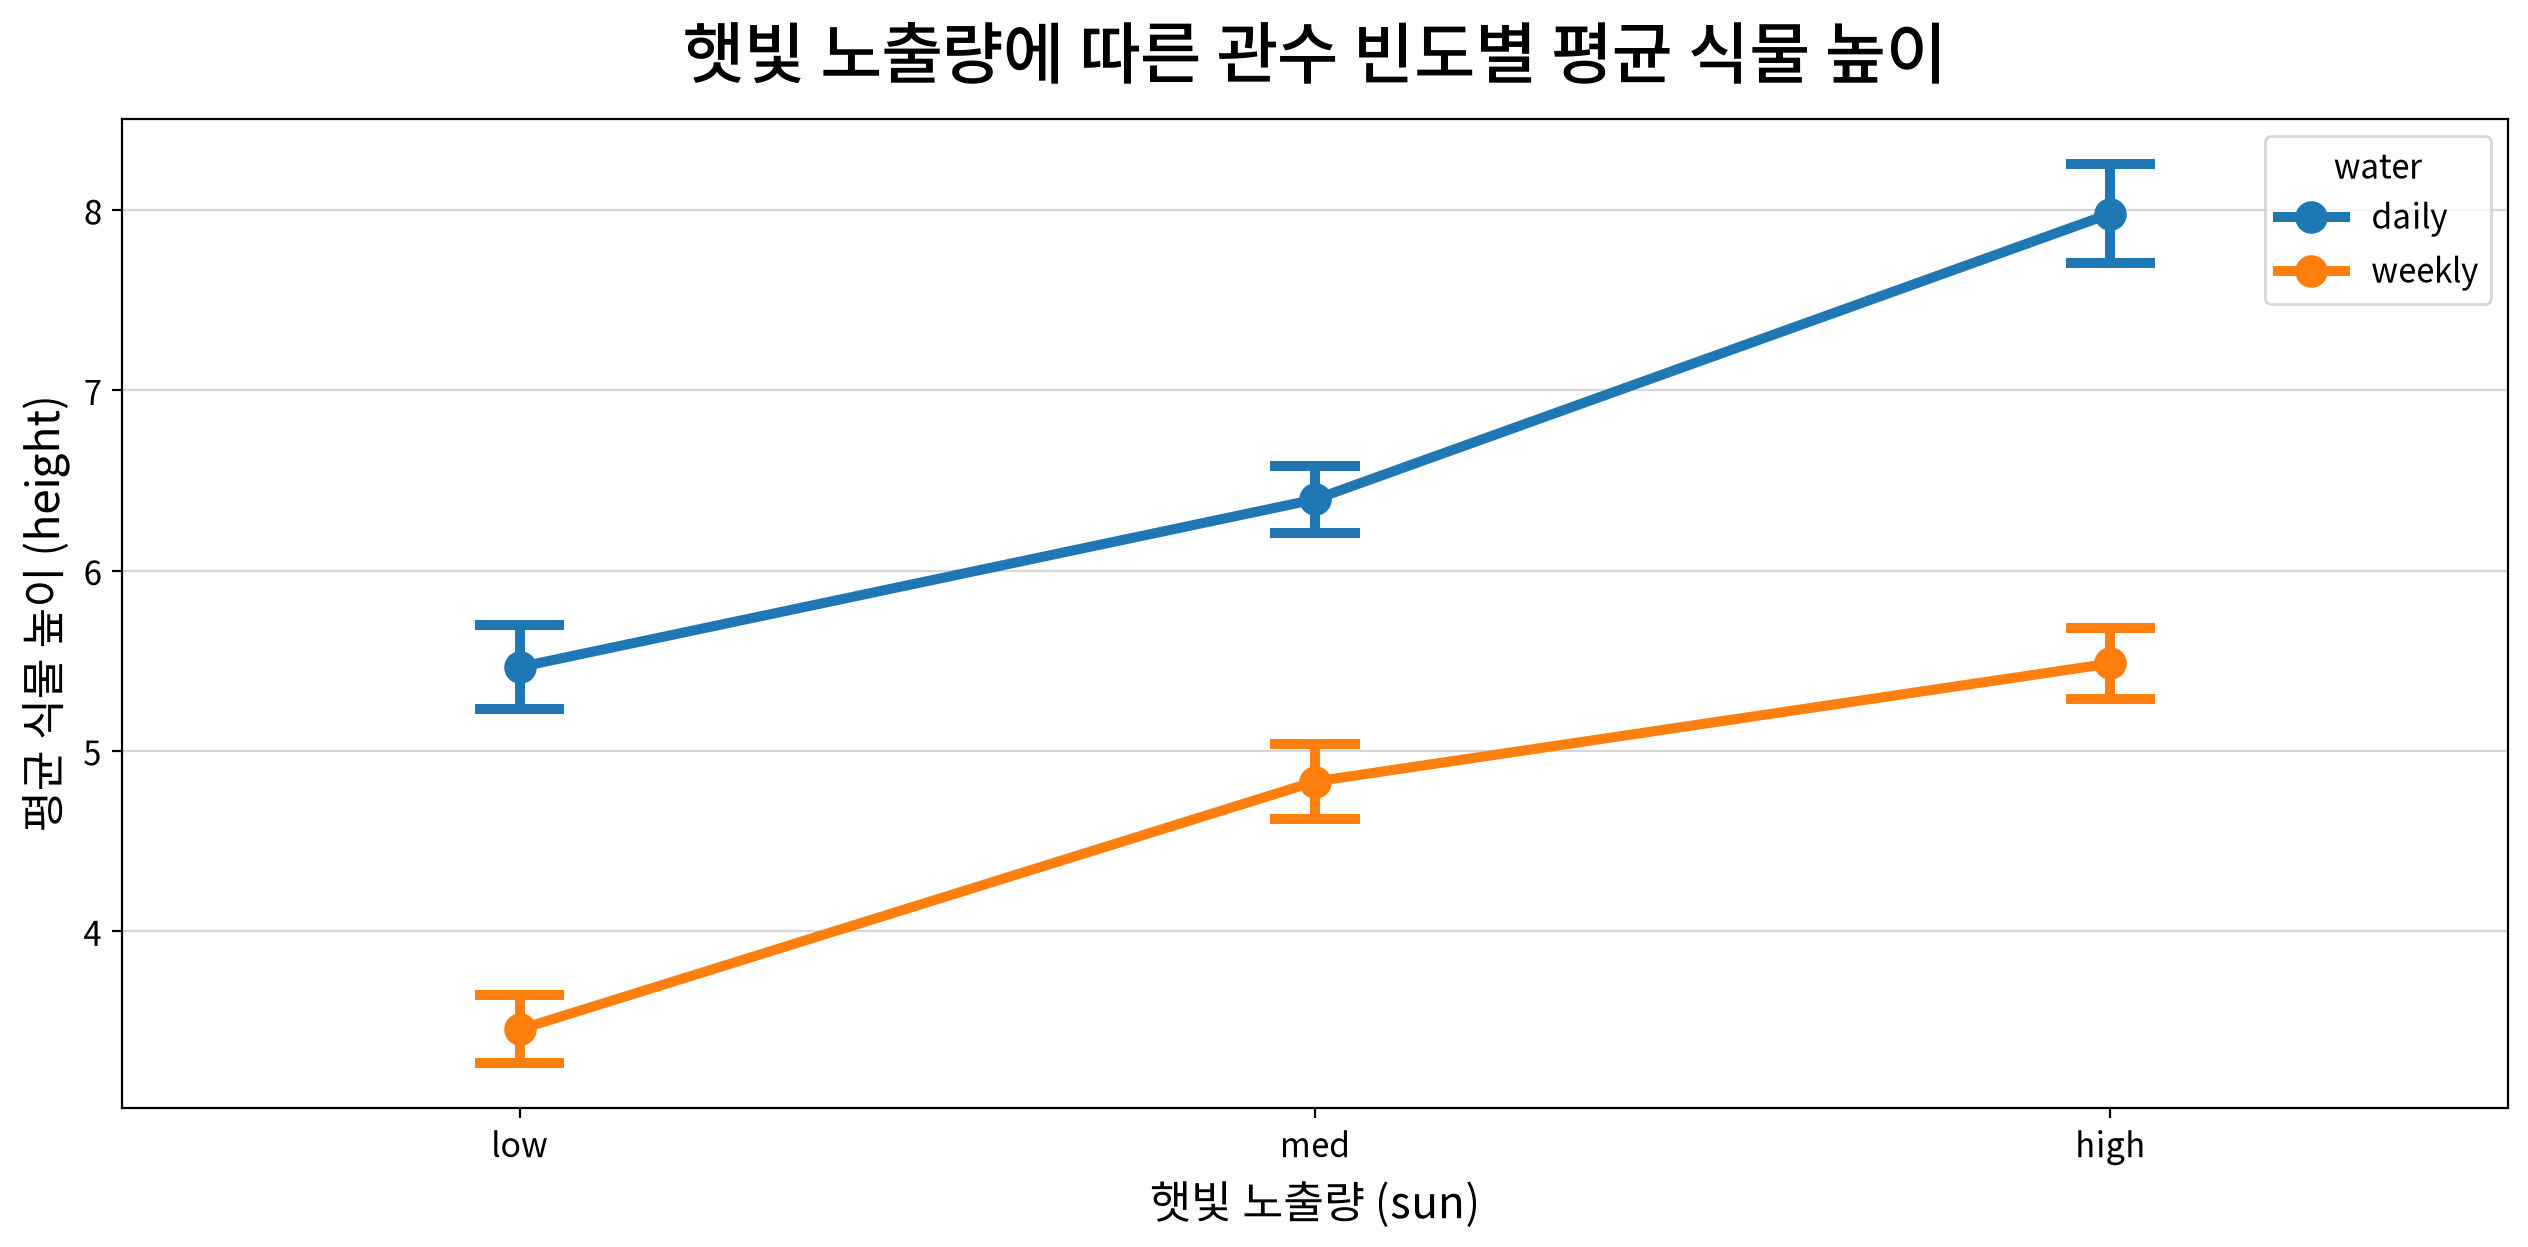

In [10]:
# 햇빛 노출량을 적은 → 많은 순으로 정렬
sun_order = ['low', 'med', 'high']

# 상호작용 플롯 — 햇빛 노출량(x축)에 따른 평균 식물 높이를 관수 빈도(선)별로 비교한다.
fig, ax = my_plot.init(title='햇빛 노출량에 따른 관수 빈도별 평균 식물 높이',
                    xlabel='햇빛 노출량 (sun)', ylabel='평균 식물 높이 (height)')

# errorbar='se' --> 표준오차(standard error)를 계산하여 오차막대(error bar) 표시
# capsizes=0.1 --> 오차막대 끝에 수평선 표시 (순전히 가독성용이라 통계적 의미 없음)
sb.pointplot(data=origin, x='sun', y='height', hue='water', 
             errorbar='se', capsize=0.1, order=sun_order, ax=ax)

my_plot.show()

### 💡 인사이트

- **햇빛(sun) 주효과**: 두 선이 모두 우상향(low → med → high)한다 → 햇빛 노출량이 많을수록 식물이 크게 자란다.
- **관수 빈도(water) 주효과**: `daily` 선이 `weekly` 선보다 항상 위에 위치한다 → 매일 물을 준 쪽이 더 크게 자란다.
- **상호작용효과(water × sun)**: 두 선이 교차하지 않고 거의 **평행**하다 → 상호작용은 미미하다(p = 0.105, 유의하지 않음).

### 2. 관수빈 도에 따른 햇빛 노출량별 평균 식물 높이

- 직전 코드를 활용하고 변수만 변경한다.

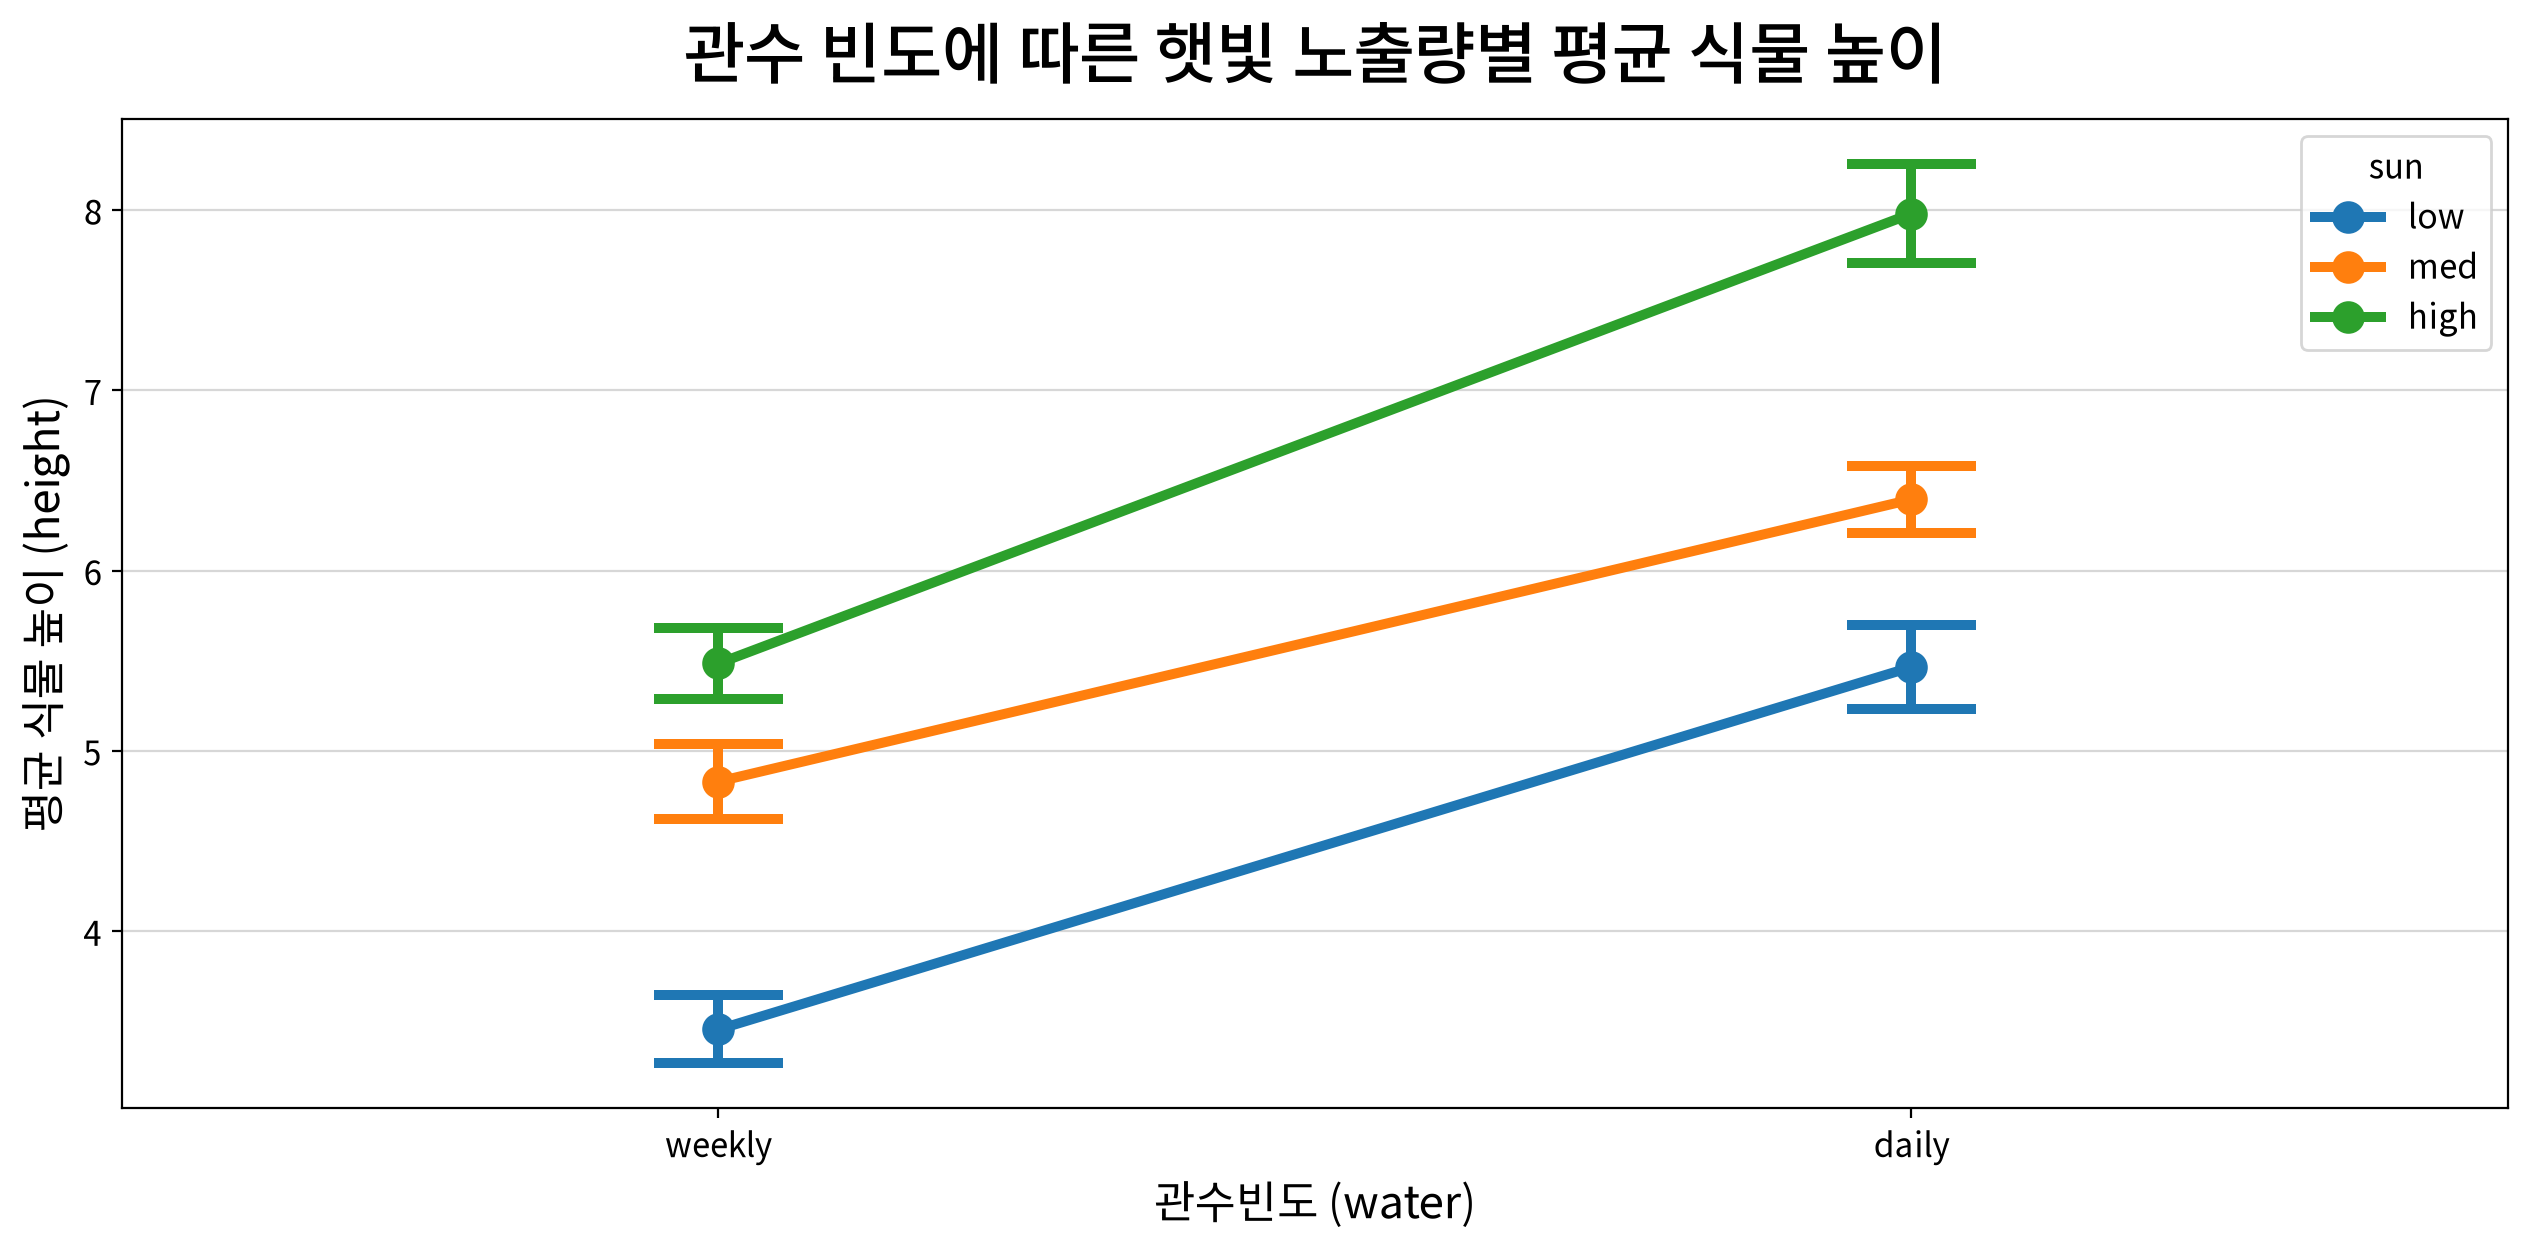

In [11]:
# 관수 빈도를 적은 → 많은 순으로 정렬
water_order = ['weekly', 'daily']

# 상호작용 플롯 — 햇빛 노출량(x축)에 따른 평균 식물 높이를 관수 빈도(선)별로 비교한다.
fig, ax = my_plot.init(title='관수 빈도에 따른 햇빛 노출량별 평균 식물 높이',
                    xlabel='관수빈도 (water)', ylabel='평균 식물 높이 (height)')

sb.pointplot(data=origin, x='water', y='height', hue='sun', 
             errorbar='se', capsize=0.1, order=water_order, ax=ax)

my_plot.show()

### 💡 인사이트

- **관수 빈도(water) 주효과**: 세 선이 모두 `weekly → daily`로 우상향한다 → 매일 물을 준 쪽이 더 크게 자란다.
- **햇빛(sun) 주효과**: `high > med > low` 순으로 선이 위에서부터 층층이 쌓여 있다 → 햇빛 노출량이 많을수록 식물이 크게 자란다.
- **상호작용효과(water × sun)**: 세 선이 서로 교차하지 않고 거의 **평행**하다 → 상호작용은 미미하다(p = 0.105, 유의하지 않음).

## #05. 모듈화 기능 확인

### 이원 분산 분석의 시각화 및 분석 결과 표

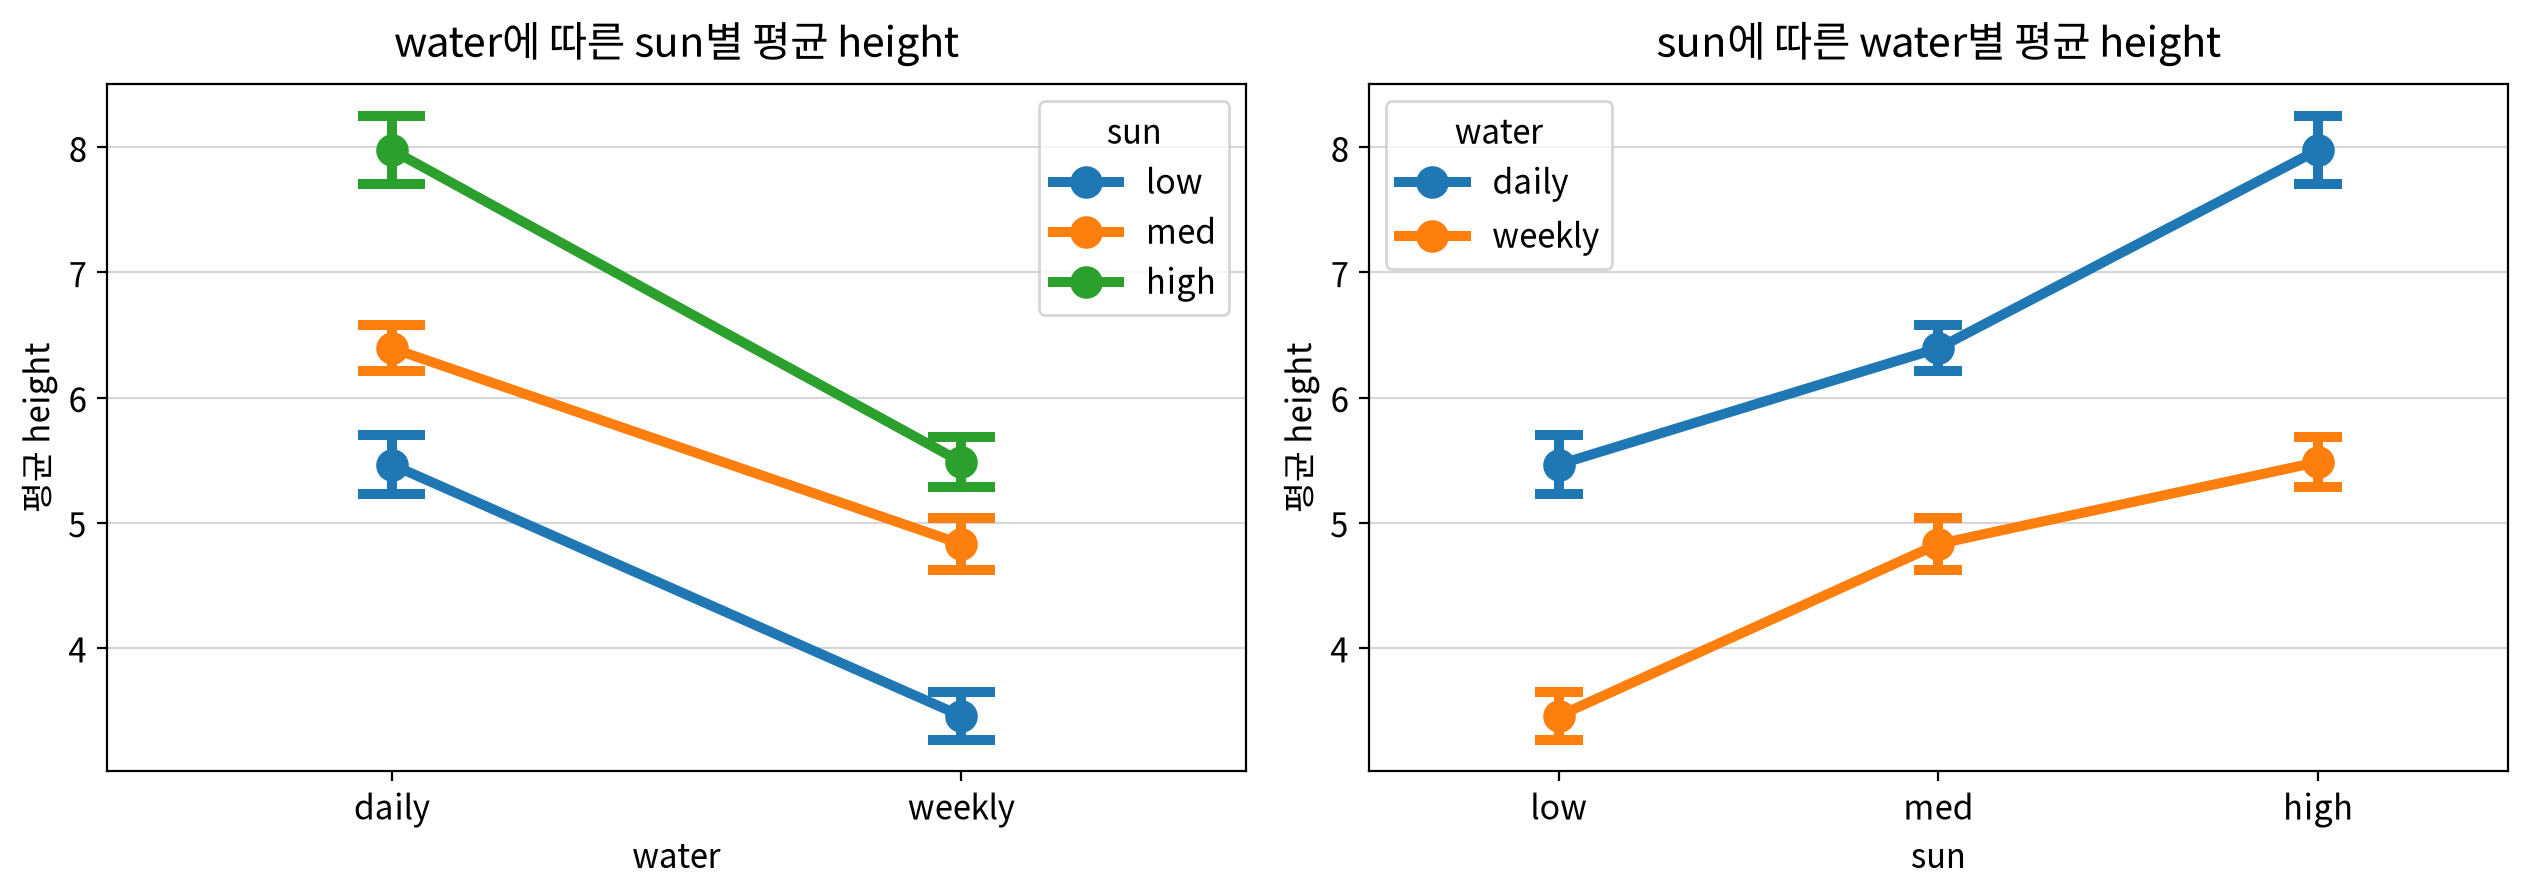

,test,Source,SS,DF,MS,F,p_unc,np2,significant,effect_size
0,two-way ANOVA,water,122.816,1,122.816,130.529,0.000,0.534,True,Large
1,two-way ANOVA,sun,103.292,2,51.646,54.889,0.000,0.491,True,Large
2,two-way ANOVA,water * sun,4.327,2,2.164,2.299,0.105,0.039,False,Small
3,two-way ANOVA,Residual,107.264,114,0.941,NaN,NaN,NaN,False,-


In [12]:
my_stats.anova_twoway(origin, y='height', between=['water', 'sun'])